In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
pd.set_option('display.max_columns', 1000)

In [2]:
from pyspark.sql.functions import sum as _sum
from pyspark.sql.functions import when, col, countDistinct, datediff, collect_set, ceil, lit
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, FloatType, StringType, DateType,  StructType, StructField, LongType

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("dash") \
    .config("spark.driver.memory", "10g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "5g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
spark.conf.set("spark.sql.shuffle.partitions", "400")
csv_file_path = "data/texasDashboardData.csv"
df = spark.read.csv(csv_file_path, header=True, inferSchema=True).drop('primary_city','area_codes')
df.show(5)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/01 15:50:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/01 15:50:20 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------------+-------------------------+--------------------+--------------------+---+------+--------------------------------+-----+-------------------------+------------------+----------------------------------+-----+------------+--------------+-----------+----------------------+---------------------------------+---------------------------------+---------------------------------+---------------------------------+---------------------------------+---------------------------------+-----------+----------------+---------------+-----------+---+------------+-----------+---------+----------+-------+----------+----------+--------------------+-----------------------------+--------------------+-------------------+------------------+-----------------------------+-----------------+--------------------+-------------------+------------------+------------------------+--------------------+-------------------------+-------------------+------------------------+-----------------------------+---------

In [4]:
print(len(df.columns))
print(df.count())
df.printSchema()

98
444545
root
 |-- Beneficiary_ID: string (nullable = true)
 |-- Assessment_Effective_Date: date (nullable = true)
 |-- Submitted_HIPPS_Code: string (nullable = true)
 |-- Facility_Internal_ID: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- American_Indian_or_Alaska_Native: double (nullable = true)
 |-- Asian: double (nullable = true)
 |-- Black_or_African_American: double (nullable = true)
 |-- Hispanic_or_Latino: double (nullable = true)
 |-- Native_Hawiian_or_Pacific_Islander: double (nullable = true)
 |-- White: double (nullable = true)
 |-- ByDiscipline: string (nullable = true)
 |-- Days_Cared_For: integer (nullable = true)
 |-- READMISSION: integer (nullable = true)
 |-- Agency_Medicare_Number: string (nullable = true)
 |-- Primary_Diagnosis_ICD_10_C_M_Code: string (nullable = true)
 |-- Other_Diagnosis_Code_1_ICD_10_C_M: string (nullable = true)
 |-- Other_Diagnosis_Code_2_ICD_10_C_M: string (nullable = true)
 |-- Other

In [5]:
df.select('Beneficiary_ID').distinct().count()

377852

In [6]:
df.columns

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'READMISSION',
 'Agency_Medicare_Number',
 'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
 'is_diabetes',
 'is_heart_failure',
 'is_hypertension',
 'is_deceased',
 'BMI',
 'BMI_Category',
 'COUNTY_NAME',
 'POP_URB',
 'POPPCT_URB',
 'POP_RUR',
 'POPPCT_RUR',
 'COUNTYFIPS',
 'ACS_PCT_BACHELOR_DGR',
 'ACS_PCT_COLLEGE_ASSOCIATE_DGR',
 'ACS_PCT_GRADUATE_DGR',
 'ACS_PCT_HS_GRADUATE',
 'ACS_PCT_LT_HS',
 'ACS_PCT_NO_WORK_NO_SCHL_16_19',
 'ACS_PCT_POSTHS_ED',
 'ACS_PCT_VET_BACHELOR',
 'ACS_PCT_VET_COLLEGE',
 'ACS_PCT_VE

In [7]:
df.printSchema()

root
 |-- Beneficiary_ID: string (nullable = true)
 |-- Assessment_Effective_Date: date (nullable = true)
 |-- Submitted_HIPPS_Code: string (nullable = true)
 |-- Facility_Internal_ID: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- American_Indian_or_Alaska_Native: double (nullable = true)
 |-- Asian: double (nullable = true)
 |-- Black_or_African_American: double (nullable = true)
 |-- Hispanic_or_Latino: double (nullable = true)
 |-- Native_Hawiian_or_Pacific_Islander: double (nullable = true)
 |-- White: double (nullable = true)
 |-- ByDiscipline: string (nullable = true)
 |-- Days_Cared_For: integer (nullable = true)
 |-- READMISSION: integer (nullable = true)
 |-- Agency_Medicare_Number: string (nullable = true)
 |-- Primary_Diagnosis_ICD_10_C_M_Code: string (nullable = true)
 |-- Other_Diagnosis_Code_1_ICD_10_C_M: string (nullable = true)
 |-- Other_Diagnosis_Code_2_ICD_10_C_M: string (nullable = true)
 |-- Other_Diagnosis

In [8]:
result_df = df.groupBy(
    'is_diabetes',
     'is_heart_failure',
     'is_hypertension',
).agg(
    # Count of unique BENE_ID
    F.countDistinct('Beneficiary_ID').alias('BENE_ID_count'),
    # Count of unique BENE_ID for Readmission_14 == 1
    F.countDistinct(F.when(df['READMISSION'] == 1, df['Beneficiary_ID'])).alias('# patients readmitted'),
    # Count of unique BENE_ID for Readmission_14 == 0
    F.countDistinct(F.when(df['READMISSION'] == 0, df['Beneficiary_ID'])).alias('# patients NOT readmitted'),
    # Count of unique BENE_ID for deceased == 1
    F.countDistinct(F.when(df['is_deceased'] == 1, df['Beneficiary_ID'])).alias('# patients deceased'),
    # Count of unique BENE_ID for deceased == 0
    F.countDistinct(F.when(df['is_deceased'] == 0, df['Beneficiary_ID'])).alias('# patients NOT deceased'),
)
result = result_df.toPandas()
result

,is_diabetes,is_heart_failure,is_hypertension,BENE_ID_count,# patients readmitted,# patients NOT readmitted,# patients deceased,# patients NOT deceased
0,0,0,0,280263,43485,270351,40517,245895
1,1,1,1,2900,1146,1893,0,2900
2,1,0,0,39612,5927,36407,0,39612
3,0,1,1,9276,3661,6110,0,9276
4,1,0,1,6368,1750,4780,0,6368
5,1,1,0,966,401,579,0,966
6,0,1,0,9744,3195,7241,0,9744
7,0,0,1,54806,8376,49243,0,54806


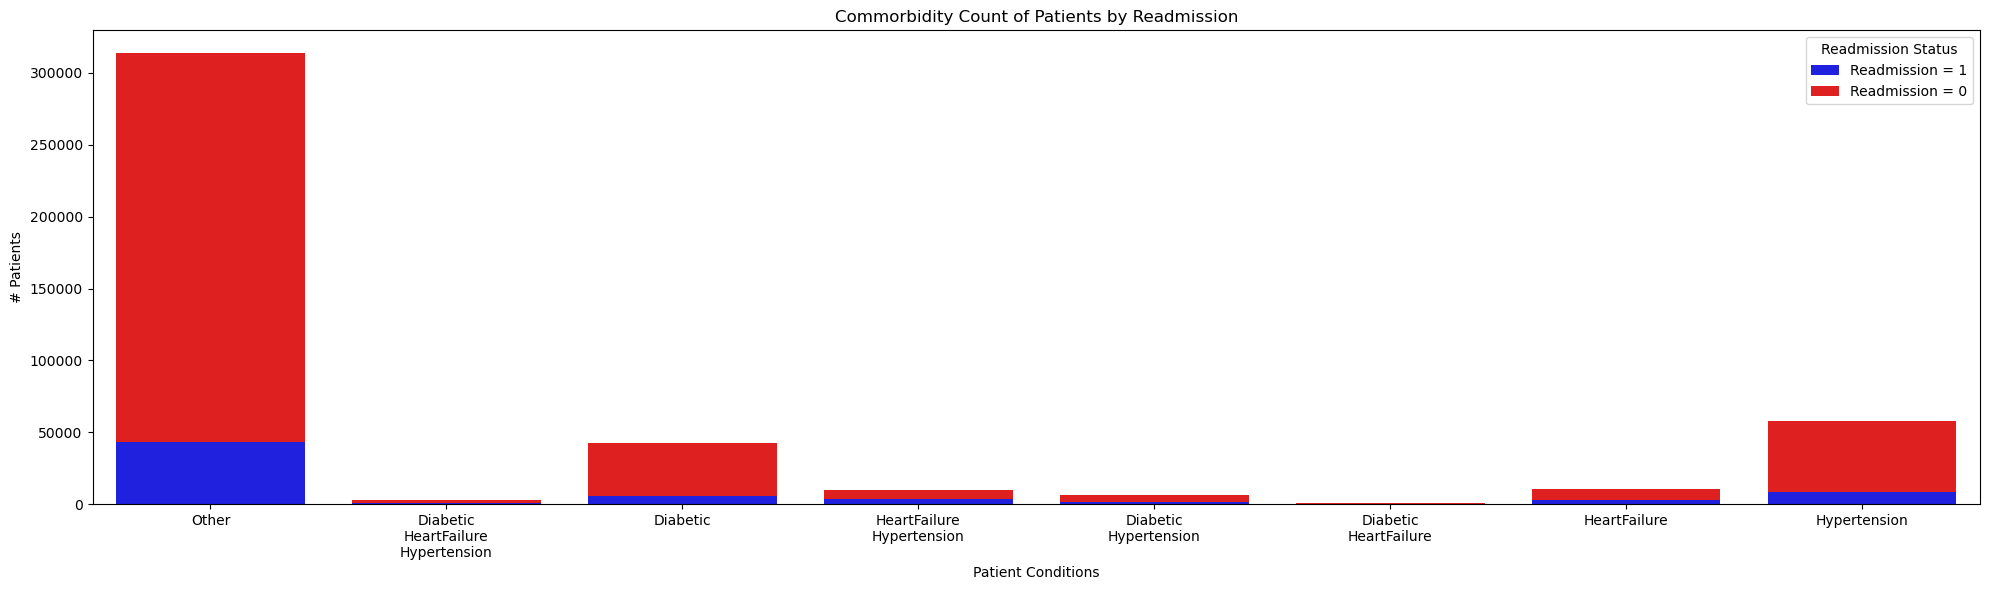

In [15]:
result['Patient_Conditions'] = result.apply(
    lambda row: '\n'.join(
        [cond for cond, condition in 
         {'Diabetic': row['is_diabetes'], 
          'HeartFailure': row['is_heart_failure'], 
          'Hypertension': row['is_hypertension']}.items() if condition == 1.0]
    ) if row['is_diabetes'] == 1.0 or row['is_heart_failure'] == 1.0 or row['is_hypertension'] == 1.0 else 'Other', 
    axis=1
)
# Set up the plot size
plt.figure(figsize=(20, 6))

# Plot a stacked bar plot
sns.barplot(x='Patient_Conditions', y='# patients readmitted', data=result, color='blue', label='Readmission = 1')
sns.barplot(x='Patient_Conditions', y='# patients NOT readmitted', data=result, color='red', label='Readmission = 0', bottom=result['# patients readmitted'])

# Add labels and title
plt.xlabel('Patient Conditions')
plt.ylabel('# Patients')
plt.title('Commorbidity Count of Patients by Readmission')

# Add a legend
plt.legend(title='Readmission Status')
plt.tight_layout()
plt.savefig('figures/ComorbidityCountByReadmission.jpg', format='jpg', bbox_inches='tight')
plt.show()

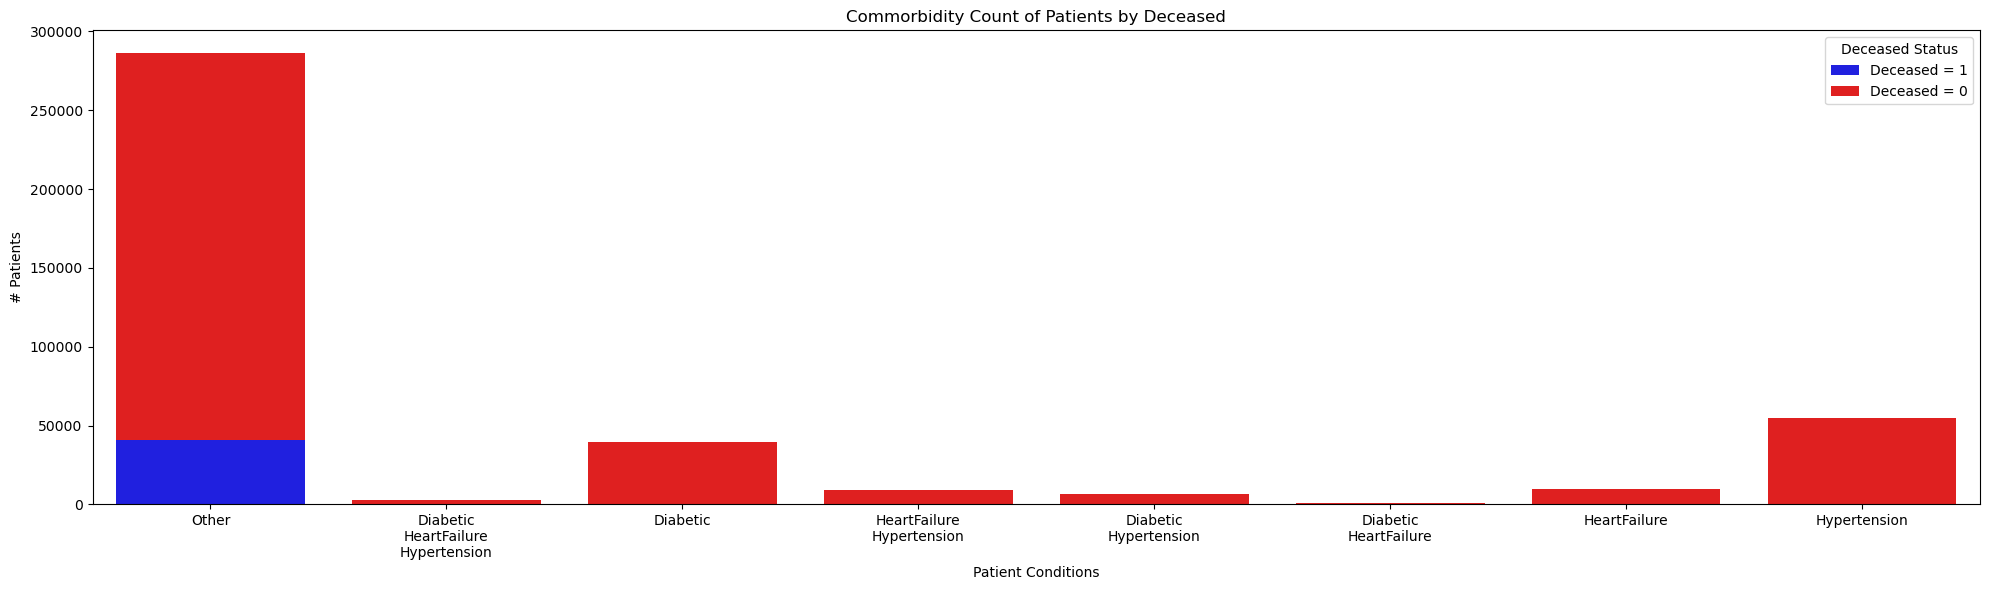

In [16]:
plt.figure(figsize=(20, 6))

# Plot a stacked bar plot
sns.barplot(x='Patient_Conditions', y='# patients deceased', data=result, color='blue', label='Deceased = 1')
sns.barplot(x='Patient_Conditions', y='# patients NOT deceased', data=result, color='red', label='Deceased = 0', bottom=result['# patients deceased'])

# Add labels and title
plt.xlabel('Patient Conditions')
plt.ylabel('# Patients')
plt.title('Commorbidity Count of Patients by Deceased')

# Add a legend
plt.legend(title='Deceased Status')
plt.tight_layout()
plt.savefig('figures/ComorbidityCountByDeceased.jpg', format='jpg', bbox_inches='tight')
plt.show()

In [17]:
df_pandas = df.toPandas().drop_duplicates()#.fillna(0)
df_pandas

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,READMISSION,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,is_diabetes,is_heart_failure,is_hypertension,is_deceased,BMI,BMI_Category,COUNTY_NAME,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_POP_POV
0,GGGGGGG99GWNzUW,2017-12-19,1CGKS,356139,75,Female,0.0,0.0,1.0,0.0,0.0,0.0,RN,0,0,679714,I11.9,I73.89,M15.0,K21.9,N39.46,None,0,0,1,0,27,Overweight,Harris,4677507.0,98.87,53638.0,1.13,48201,20.002284,25.887536,11.996951,22.838174,19.185522,1.939011,57.886619,31.882239,36.757860,28.122410,12.653121,68.342320,6.312617,78.048615,14.276799,0.141951,85.394164,2.052950,7.455809,12.283121,2.412104,0.018714,74.575108,3.227824,7.685683,86.899218,12.036313,59.834092,0.734829,8.129937,33.536888,38.805908,10.236151,24.519155,26.830728,21.947275,7.247464,21.881277,93.839029,12.250612,28.372572,34.331007,24.776376,24.694119,6.257833,9.230647,14.404757,7.291655,4.506214,14.438022,5.353849,14.852644,62.705198,16.818489,6.254451,11.774038,17.916232,18.082023,14.639892,0.612113,17.751070,13.141808,9.128750,4167.452338
1,GGGGGGG99NWze9G,2017-01-13,1CFKS,83192,74,Male,NaN,NaN,NaN,NaN,NaN,NaN,RN,949,0,679372,I25.10,I50.9,I11.0,J44.1,R32.,Z51.81,0,0,0,0,0,Underweight,Bowie,57646.0,62.06,35247.0,37.94,48037,13.153846,33.281923,7.370769,35.667308,10.525000,0.661154,53.806923,20.079231,41.513846,38.408077,0.795769,54.897692,7.666923,61.746154,13.377692,0.351154,72.049615,3.468846,20.300000,24.481154,1.093462,0.120000,63.823462,4.888077,16.515769,72.741538,11.768846,33.311538,0.359231,14.919231,39.696923,26.125769,26.372308,43.655769,30.853077,32.633846,12.482308,21.652692,111.923077,13.427692,31.598077,30.037692,24.936923,25.905000,7.215769,11.689615,12.323077,8.606538,3.174615,16.306538,5.153846,15.103462,61.638077,18.105000,2.220769,3.846154,19.703462,11.421923,22.495000,3.846154,6.445769,15.411538,14.380769,3376.115385
2,GGGGGGG99NeDX99,2017-03-01,4BGKS,1472419,72,Female,NaN,NaN,NaN,NaN,NaN,NaN,RN,397,0,747517,E11.22,I13.2,I50.9,N18.6,I48.2,D63.1,1,0,0,0,0,Underweight,Harris,4677507.0,98.87,53638.0,1.13,48201,20.002284,25.887536,11.996951,22.838174,19.185522,1.939011,57.886619,31.882239,36.757860,28.122410,12.653121,68.3

In [18]:
df_pandas['Beneficiary_ID'].nunique()

377852

In [19]:
df_pandas.to_csv('data/dashboardData_v2.csv', index=False)

In [21]:
df_pandas.dtypes

Beneficiary_ID                object
Assessment_Effective_Date     object
Submitted_HIPPS_Code          object
Facility_Internal_ID           int32
Age                            int32
                              ...   
ACS_PCT_POV_OTHER            float64
ACS_PCT_POV_WHITE            float64
ACS_PCT_VET_POV_18_64        float64
ACS_TOT_POP_POV              float64
num_populated_diag             int64
Length: 99, dtype: object

In [22]:
diag_columns = [
    'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M'
]

df_pandas["num_populated_diag"] = df_pandas[diag_columns].notna().sum(axis=1)

df_summary = df_pandas.groupby("num_populated_diag")["Beneficiary_ID"].nunique().reset_index()
df_summary.columns = ["Populated Diagnosis Columns", "Number of Unique Patients"]
df_summary

,Populated Diagnosis Columns,Number of Unique Patients
0,0,40517
1,1,927
2,2,2671
3,3,7083
4,4,15075
5,5,25620
6,6,301670


In [23]:
df_melted = df_pandas.melt(id_vars=["Beneficiary_ID", "Age"], 
                             value_vars=['Primary_Diagnosis_ICD_10_C_M_Code',
                                         'Other_Diagnosis_Code_1_ICD_10_C_M',
                                         'Other_Diagnosis_Code_2_ICD_10_C_M',
                                         'Other_Diagnosis_Code_3_ICD_10_C_M',
                                         'Other_Diagnosis_Code_4_ICD_10_C_M',
                                         'Other_Diagnosis_Code_5_ICD_10_C_M'], 
                             var_name="Diagnosis_Type", value_name="ICD_Code").drop_duplicates()

In [24]:
df_melted

,Beneficiary_ID,Age,Diagnosis_Type,ICD_Code
0,GGGGGGG99GWNzUW,75,Primary_Diagnosis_ICD_10_C_M_Code,I11.9
1,GGGGGGG99NWze9G,74,Primary_Diagnosis_ICD_10_C_M_Code,I25.10
2,GGGGGGG99NeDX99,72,Primary_Diagnosis_ICD_10_C_M_Code,E11.22
3,GGGGGGG99S9eeNG,74,Primary_Diagnosis_ICD_10_C_M_Code,E11.9
4,GGGGGGG99SeUG9X,59,Primary_Diagnosis_ICD_10_C_M_Code,E11.9
...,...,...,...,...
2667265,GGGGGGXzeeXXUeN,66,Other_Diagnosis_Code_5_ICD_10_C_M,None
2667266,GGGGGGXzezDGz9U,69,Other_Diagnosis_Code_5_ICD_10_C_M,F10.20
2667267,GGGGGGXzezDW9WN,66,Other_Diagnosis_Code_5_ICD_10_C_M,None
2667268,GGGGGGXzezXDeDW,61,Other_Diagnosis_Code_5_ICD_10_C_M,I73.9


In [25]:
df_melted['Beneficiary_ID'].nunique()

377852

In [26]:
df_melted = df_melted.rename(columns={"Beneficiary_ID": "BENE_ID"})

## Comorbidity, HFRS, and Disability & Impairment Scores

**comorbidipy 0.5.0 depends on pandas>=1.4.0**

In [27]:
import comorbidipy
#SOURCE: https://github.com/vvcb/comorbidipy/blob/main/comorbidipy/calculator.py
#~/miniconda3/envs/ai_env/lib/python3.10/site-packages/cd comorbidipy/calculator.py
# CHANGED: from pandas.core.common import SettingWithCopyWarning
# TO: from pandas.errors import SettingWithCopyWarning


# I also manually changed the hardcoded id, code, & age

### Calculate Charlson and Elixhauser Comorbidity Scores from ICD codes

Calculation:

    The comorbidity score is calculated based on the presence of specific ICD  codes in the dataset.
    The calculation involves:
        Mapping ICD codes: The ICD codes are mapped to a predefined comorbidity score (e.g., Charlson Comorbidity Index).
        Weighting: Different conditions (ICD codes) are assigned a weight based on their severity. These weights contribute to the total comorbidity score.
        Age Adjustment: An age-adjusted comorbidity score is calculated by adding points for patients based on their age, with older patients receiving higher adjustments.
        Final Score: The final comorbidity score reflects the accumulated comorbidity and age adjustments.

Returns dataframe with one row per id. The dataframe will contain comorbidities in columns as well as a comorbidity_score column. 

If score`==”charlson” and `age is given, age_adjusted_comorbidity_score and survival_10yr are calculated as below.

age_adjusted_comorbidity_score = comorbidity_score + 1 point for every decade over 40 upto a maximum of 4 points


In [28]:
df_out = comorbidipy.comorbidity(df_melted,  
                     id="BENE_ID",
                     code="ICD_Code",
                     age="Age",
                     score="charlson",
                     icd="icd10",
                     variant="quan",
                     weighting="quan",
                     assign0=True)
df_out

,BENE_ID,Age,aids,ami,canc,cevd,chf,copd,dementia,hp,metacanc,mld,pud,pvd,rend,rheumd,diab,diabwc,msld,comorbidity_score,age_adj_comorbidity_score
0,GGGGGGG99GWNzUW,75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1,GGGGGGG99NWze9G,74,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,6.0
2,GGGGGGG99NeDX99,72,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,6.0
3,GGGGGGG99S9eeNG,74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
4,GGGGGGG99SeUG9X,59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347397,GGGGGGXzee9eeSX,64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0
347398,GGGGGGXzeeXXUeN,66,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
347399,GGGGGGXzezDW9WN,66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
347400,GGGGGGXzezXDeDW,61,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0


In [29]:
df_out.columns

Index(['BENE_ID', 'Age', 'aids', 'ami', 'canc', 'cevd', 'chf', 'copd',
       'dementia', 'hp', 'metacanc', 'mld', 'pud', 'pvd', 'rend', 'rheumd',
       'diab', 'diabwc', 'msld', 'comorbidity_score',
       'age_adj_comorbidity_score'],
      dtype='object')

In [30]:
df_out['weight'] = 'Charlson'

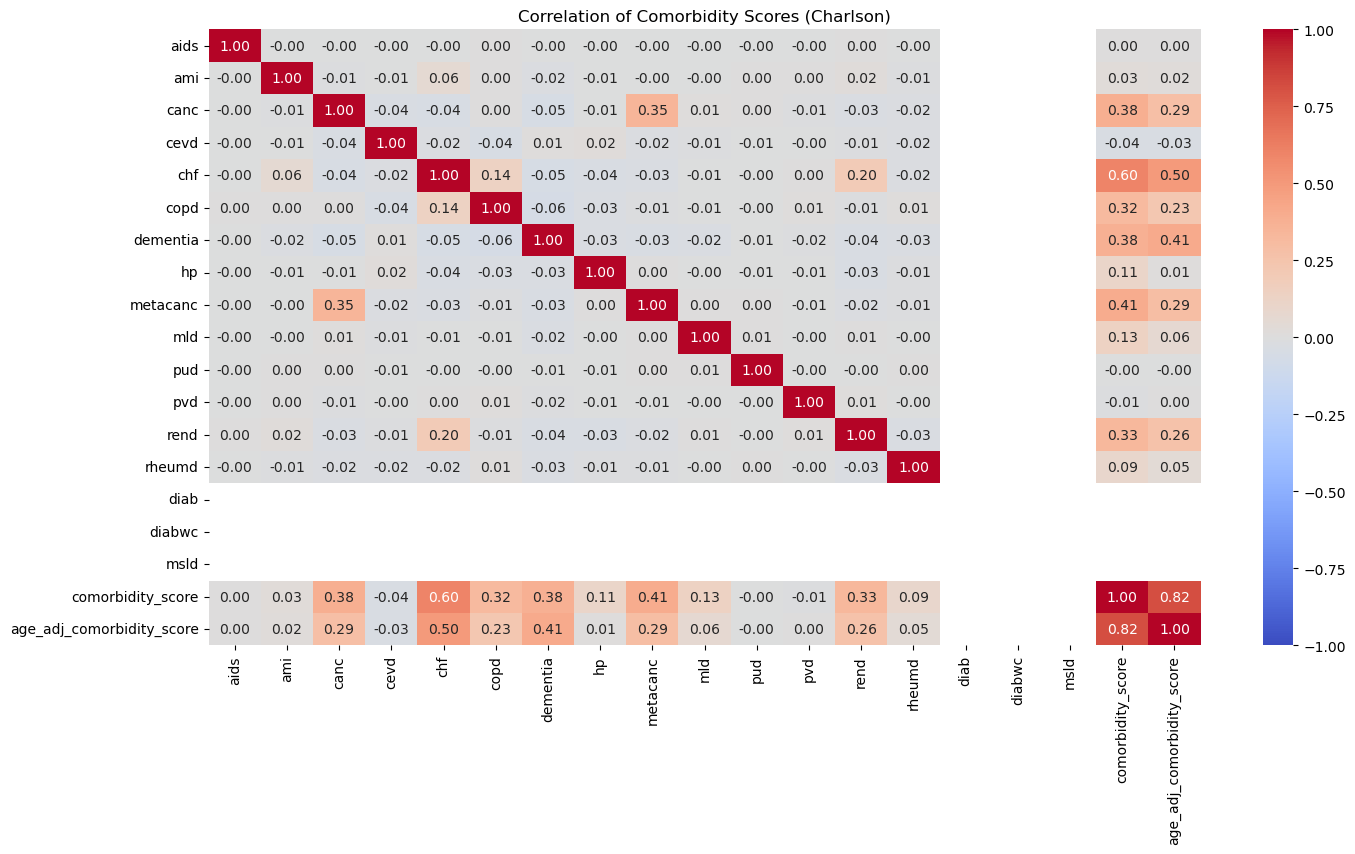

In [31]:
correlation_swiss = df_out[['aids', 'ami', 'canc', 'cevd', 'chf', 'copd',
       'dementia', 'hp', 'metacanc', 'mld', 'pud', 'pvd', 'rend', 'rheumd',
       'diab', 'diabwc', 'msld', 'comorbidity_score',
       'age_adj_comorbidity_score']].corr()
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_swiss, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation of Comorbidity Scores (Charlson)')
plt.show()

In [32]:
df_out.attrs

{'score': 'charlson',
 'icd': 'icd10',
 'variant': 'quan',
 'weighting': 'quan',
 'assign0': True}

#### Elixhauser

In [33]:
comorbidity_cols = ['aids', 'alcohol', 'carit', 'chf', 'coag', 'cpd',
       'dane', 'depre', 'drug', 'fed', 'hypc', 'hypothy', 'hypunc', 'ld',
       'lymph', 'metacanc', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pvd',
       'rf', 'rheumd', 'solidtum', 'valv', 'wloss', 'blane', 'diabc',
       'diabunc', 'pud', 'comorbidity_score', 'age_adj_comorbidity_score']


The Elixhauser indices, c-statistic with Swiss weights (0.867, 95% CI, 0.865–0.868) and van Walraven’s
weights (0.863, 95% CI, 0.862–0.864) had substantial advantage over Charlson’s weights (0.850, 95% CI, 0.849–0.851)
and in the derivation and validation groups. [Source](https://www.researchgate.net/publication/348278874_Comparing_Charlson_and_Elixhauser_comorbidity_indices_with_different_weightings_to_predict_in-hospital_mortality_an_analysis_of_national_inpatient_data) 

In [34]:
# Elixhauser-compatible weights:
# van Walraven
df_out_elix = comorbidipy.comorbidity(df_melted,  
                     id="BENE_ID",
                     code="ICD_Code",
                     age="Age",
                     score="elixhauser",
                     icd="icd10",
                     variant="quan",
                     weighting="vw",
                     assign0=True)
df_out_elix

,BENE_ID,Age,aids,alcohol,carit,chf,coag,cpd,dane,depre,drug,fed,hypc,hypothy,hypunc,ld,lymph,metacanc,obes,ond,para,pcd,psycho,pvd,rf,rheumd,solidtum,valv,wloss,blane,diabc,diabunc,pud,comorbidity_score,age_adj_comorbidity_score
0,GGGGGGG99GWNzUW,75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1,GGGGGGG99NWze9G,74,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,13.0
2,GGGGGGG99NeDX99,72,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,20.0
3,GGGGGGG99S9eeNG,74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
4,GGGGGGG99SeUG9X,59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347397,GGGGGGXzee9eeSX,64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,9.0
347398,GGGGGGXzeeXXUeN,66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
347399,GGGGGGXzezDW9WN,66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,13.0
347400,GGGGGGXzezXDeDW,61,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,13.0


In [35]:
df_out_elix['weight'] = 'Van Walraven'

In [36]:
correlation_van = df_out_elix[comorbidity_cols].corr()

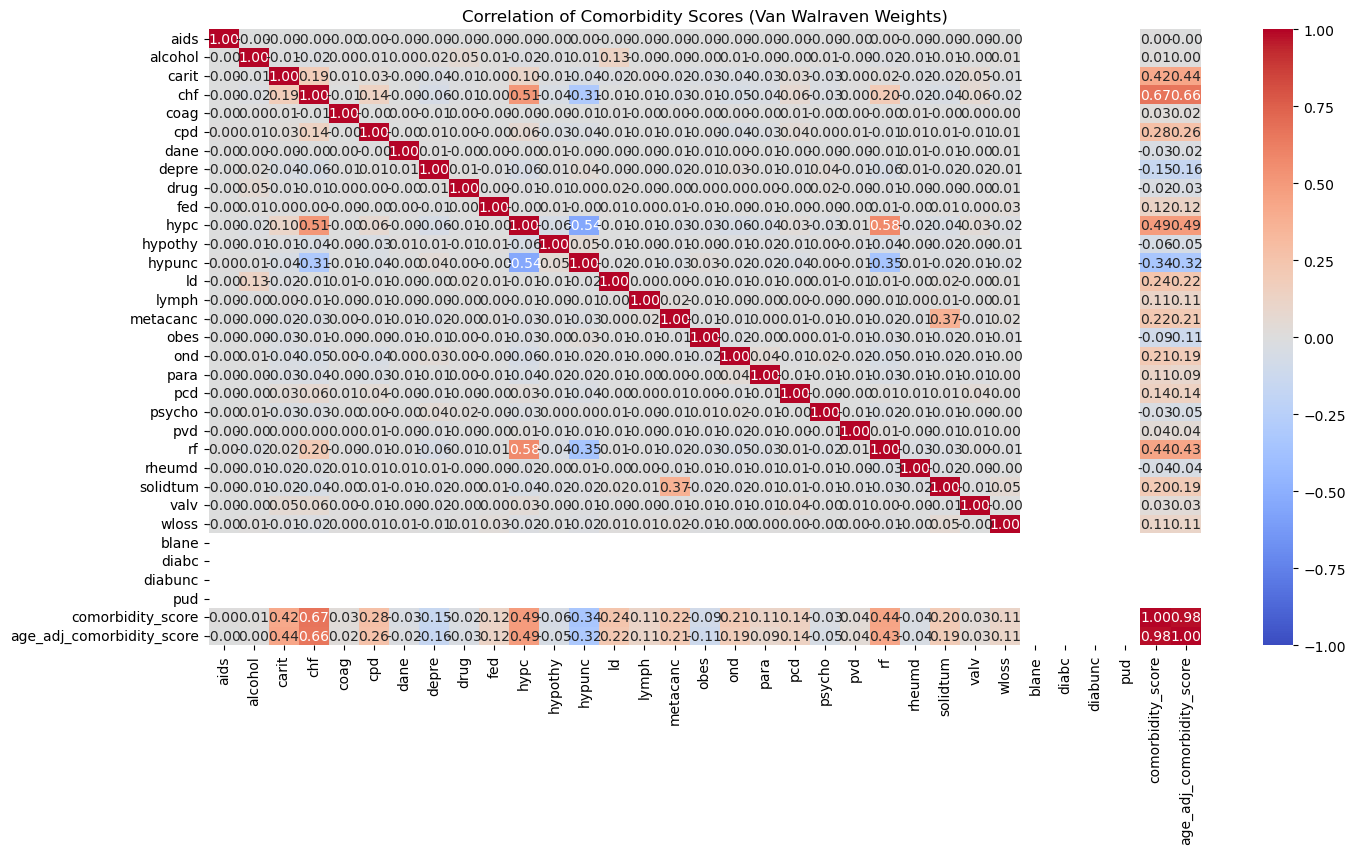

In [37]:
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_van, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation of Comorbidity Scores (Van Walraven Weights)')
plt.show()


In [38]:
# Elixhauser-compatible weights:
# swiss weights
df_out_elix_ = comorbidipy.comorbidity(df_melted,  
                     id="BENE_ID",
                     code="ICD_Code",
                     age="Age",
                     score="elixhauser",
                     icd="icd10",
                     variant="quan",
                     weighting="swiss",
                     assign0=True)
df_out_elix_

,BENE_ID,Age,aids,alcohol,carit,chf,coag,cpd,dane,depre,drug,fed,hypc,hypothy,hypunc,ld,lymph,metacanc,obes,ond,para,pcd,psycho,pvd,rf,rheumd,solidtum,valv,wloss,blane,diabc,diabunc,pud,comorbidity_score,age_adj_comorbidity_score
0,GGGGGGG99GWNzUW,75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1,GGGGGGG99NWze9G,74,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,16.0
2,GGGGGGG99NeDX99,72,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,27.0
3,GGGGGGG99S9eeNG,74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
4,GGGGGGG99SeUG9X,59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347397,GGGGGGXzee9eeSX,64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,13.0
347398,GGGGGGXzeeXXUeN,66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
347399,GGGGGGXzezDW9WN,66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,14.0
347400,GGGGGGXzezXDeDW,61,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,14.0


In [39]:
df_out_elix_['weight'] = 'Swiss'

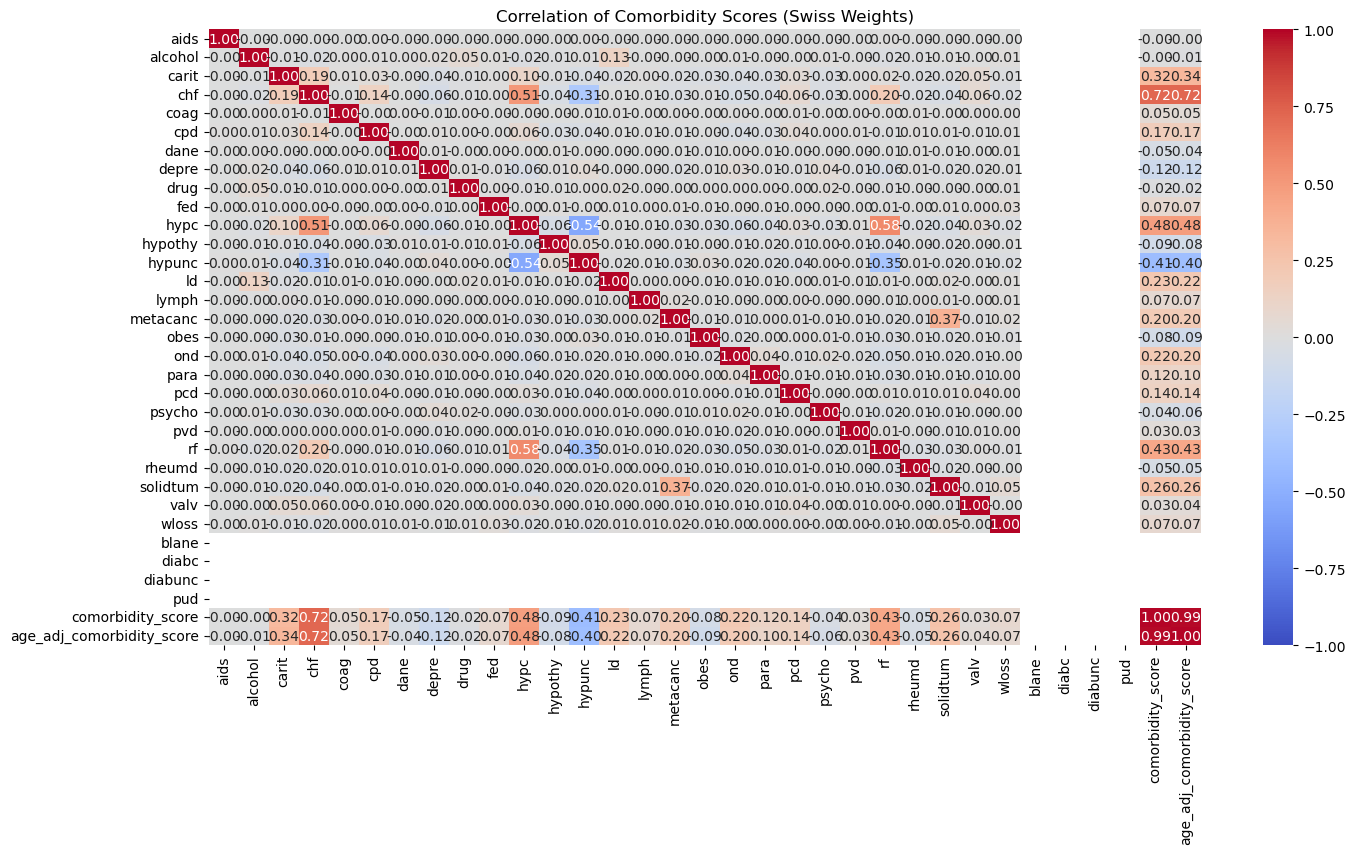

In [40]:
correlation_swiss = df_out_elix_[comorbidity_cols].corr()
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_swiss, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation of Comorbidity Scores (Swiss Weights)')
plt.show()

    CHF focuses on heart failure conditions, which affect the heart's ability to pump blood.
    Hypunc is for uncomplicated hypertension (high blood pressure).
    Hypc involves hypertension with complications affecting other organs such as the heart and kidneys.
    RF deals with conditions that primarily affect the kidneys, including chronic kidney disease and renal failure, as well as conditions where hypertension has led to kidney damage.

In [41]:
df_out_elix_.columns

Index(['BENE_ID', 'Age', 'aids', 'alcohol', 'carit', 'chf', 'coag', 'cpd',
       'dane', 'depre', 'drug', 'fed', 'hypc', 'hypothy', 'hypunc', 'ld',
       'lymph', 'metacanc', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pvd',
       'rf', 'rheumd', 'solidtum', 'valv', 'wloss', 'blane', 'diabc',
       'diabunc', 'pud', 'comorbidity_score', 'age_adj_comorbidity_score',
       'weight'],
      dtype='object')

In [42]:
df_combined = pd.concat([df_out_elix, df_out_elix_, df_out])
df_combined

,BENE_ID,Age,aids,alcohol,carit,chf,coag,cpd,dane,depre,drug,fed,hypc,hypothy,hypunc,ld,lymph,metacanc,obes,ond,para,pcd,psycho,pvd,rf,rheumd,solidtum,valv,wloss,blane,diabc,diabunc,pud,comorbidity_score,age_adj_comorbidity_score,weight,ami,canc,cevd,copd,dementia,hp,mld,rend,diab,diabwc,msld
0,GGGGGGG99GWNzUW,75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,Van Walraven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GGGGGGG99NWze9G,74,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,13.0,Van Walraven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GGGGGGG99NeDX99,72,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,20.0,Van Walraven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GGGGGGG99S9eeNG,74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,Van Walraven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GGGGGGG99SeUG9X,59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Van Walraven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347397,GGGGGGXzee9eeSX,64,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,4.0,Charlson,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
347398,GGGGGGXzeeXXUeN,66,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,2.0,Charlson,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
347399,GGGGGGXzezDW9WN,66,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,2.0,Charlson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
347400,GGGGGGXzezXDeDW,61,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,4.0,Charlson,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


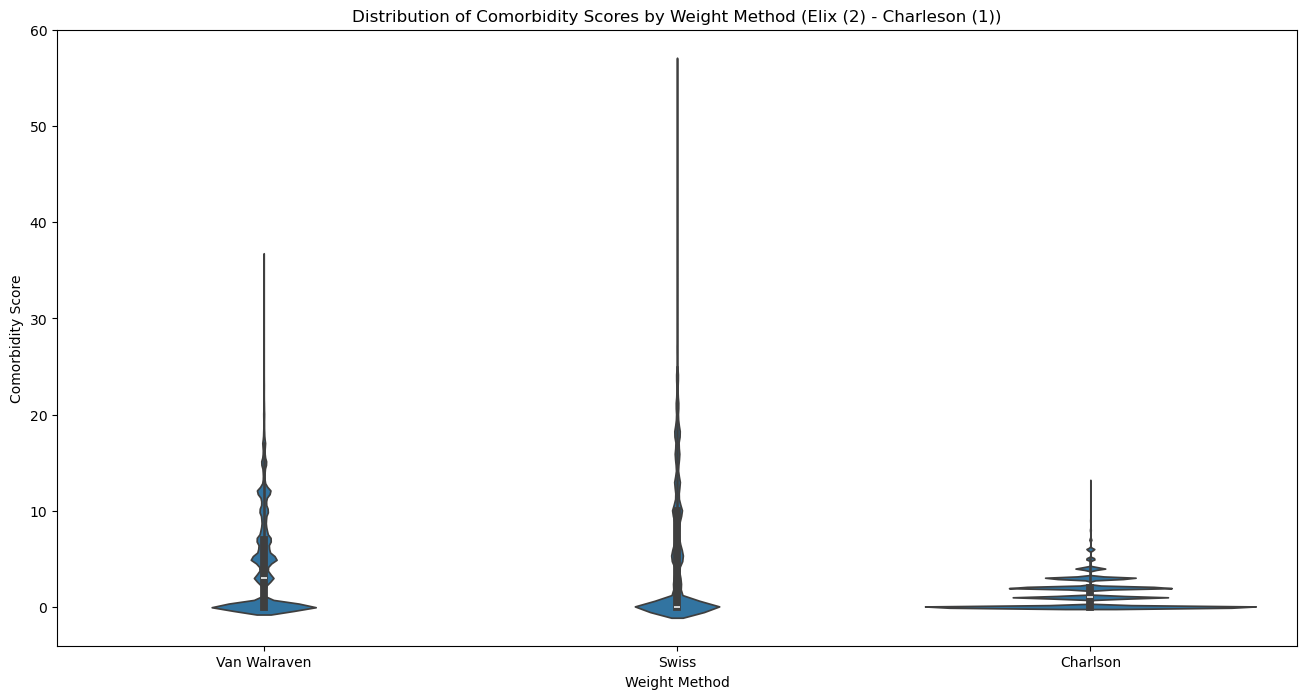

In [43]:
plt.figure(figsize=(16, 8))
sns.violinplot(x='weight', y='comorbidity_score', data=df_combined)

# Title and labels
plt.title('Distribution of Comorbidity Scores by Weight Method (Elix (2) - Charleson (1))')
plt.xlabel('Weight Method')
plt.ylabel('Comorbidity Score')

plt.show()

### Identify disabilities and sensory impairments from ICD10 codes

In [44]:
df_out_dis = comorbidipy.disability(df_melted,  
                     id="BENE_ID",
                     code="ICD_Code",
                     )
df_out_dis

,BENE_ID,frail,impaired_hearing,impaired_speech,impaired_vision,ld_asd
0,GGGGGGG99GWNzUW,0.0,0.0,0.0,0.0,0.0
1,GGGGGGG99NWze9G,0.0,0.0,0.0,0.0,0.0
2,GGGGGGG99NeDX99,0.0,0.0,0.0,0.0,0.0
3,GGGGGGG99S9eeNG,0.0,0.0,0.0,0.0,0.0
4,GGGGGGG99SeUG9X,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
347397,GGGGGGXzee9eeSX,0.0,0.0,0.0,0.0,0.0
347398,GGGGGGXzeeXXUeN,0.0,0.0,0.0,0.0,0.0
347399,GGGGGGXzezDW9WN,0.0,0.0,0.0,0.0,0.0
347400,GGGGGGXzezXDeDW,0.0,0.0,0.0,0.0,0.0


### Calculate Hospital Frailty Risk Score
The final HFRS for each patient is calculated by adding the weighted points together for each code present from the index admission with any diagnosis recorded from previous admissions during the previous two years. HFRS was categorised as low frailty risk (<5), intermediate frailty risk (5–15), and high frailty risk (>15) [Source](https://pmc.ncbi.nlm.nih.gov/articles/PMC11756769/)

Found [HFRS](https://pmc.ncbi.nlm.nih.gov/articles/PMC10772247/) to be superior compared to CCI, ECI, CirCom. "HFRS is an ideal tool for measuring comorbidity burden and disease severity risk adjustment in cirrhosis-related administrative database studies."

In [45]:
#This is only applicable to patients who are 75 years or older.
# SOURCE: https://www.thelancet.com/journals/lancet/article/PIIS0140-6736(18)30668-8
df_75 = df_melted[df_melted['Age'] >= 75.0]

In [46]:
df_out_75 = comorbidipy.hfrs(df_75,  
                     id="BENE_ID",
                     code="ICD_Code",
                     )
df_out_75

/home/m_e172/miniconda3/envs/ai_env/lib/python3.10/site-packages/comorbidipy/calculator.py:206: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["hfrs"] = df[code].replace(hfrs_mapping)


,BENE_ID,hfrs
0,GGGGGGG99GWNzUW,3.6
1,GGGGGGG99W9SGUD,0.0
2,GGGGGGG9DDXUDSW,2.3
3,GGGGGGG9DDeGWWX,1.5
4,GGGGGGG9G9D9S9D,2.5
...,...,...
192534,GGGGGGUUeWDUSGU,2.9
192535,GGGGGGUeXSXNz9z,3.6
192536,GGGGGGUezDNU9WU,0.0
192537,GGGGGGXDGXWGUGS,0.9


In [47]:
df_merged = df_out_75.merge(df_out_dis, on='BENE_ID')
df_merged

,BENE_ID,hfrs,frail,impaired_hearing,impaired_speech,impaired_vision,ld_asd
0,GGGGGGG99GWNzUW,3.6,0.0,0.0,0.0,0.0,0.0
1,GGGGGGG99W9SGUD,0.0,0.0,0.0,0.0,0.0,0.0
2,GGGGGGG9DDXUDSW,2.3,0.0,0.0,0.0,0.0,0.0
3,GGGGGGG9DDeGWWX,1.5,0.0,0.0,0.0,0.0,0.0
4,GGGGGGG9G9D9S9D,2.5,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
192534,GGGGGGUUeWDUSGU,2.9,0.0,0.0,0.0,0.0,0.0
192535,GGGGGGUeXSXNz9z,3.6,0.0,0.0,0.0,0.0,0.0
192536,GGGGGGUezDNU9WU,0.0,0.0,0.0,0.0,0.0,0.0
192537,GGGGGGXDGXWGUGS,0.9,0.0,0.0,0.0,0.0,0.0


In [48]:
df_merged.columns

Index(['BENE_ID', 'hfrs', 'frail', 'impaired_hearing', 'impaired_speech',
       'impaired_vision', 'ld_asd'],
      dtype='object')

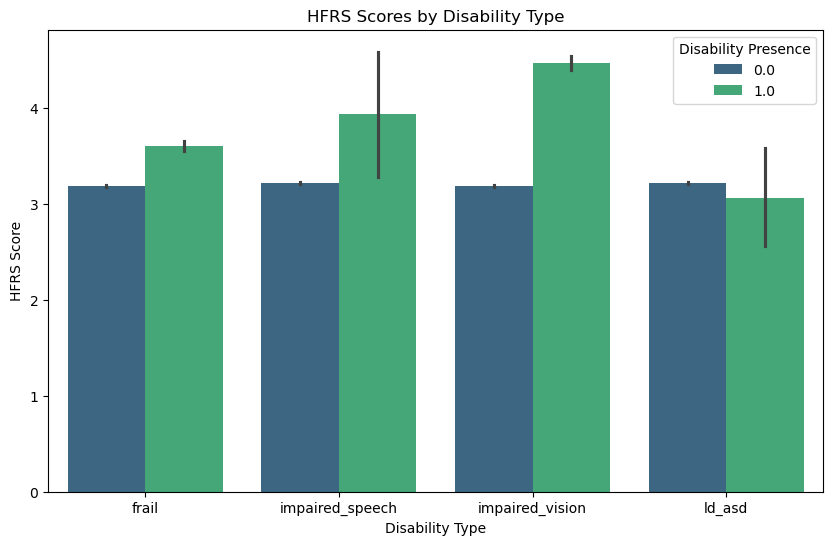

In [49]:
df_melt = df_merged.melt(id_vars=['BENE_ID', 'hfrs'], value_vars=['frail', 'impaired_speech', 'impaired_vision', 'ld_asd'], 
                    var_name='Disability', value_name='Presence')

# Create a barplot to show HFRS scores for different disabilities
plt.figure(figsize=(10, 6))
sns.barplot(x='Disability', y='hfrs', hue='Presence', data=df_melt, palette='viridis')

# Title and labels
plt.title('HFRS Scores by Disability Type')
plt.xlabel('Disability Type')
plt.ylabel('HFRS Score')
plt.legend(title='Disability Presence', loc='upper right')

# Show plot
plt.show()

In [50]:
df_final = df_combined.merge(df_merged, on='BENE_ID', how='outer').fillna(0).drop_duplicates()
print(df_final['BENE_ID'].nunique())
df_final

347402


,BENE_ID,Age,aids,alcohol,carit,chf,coag,cpd,dane,depre,drug,fed,hypc,hypothy,hypunc,ld,lymph,metacanc,obes,ond,para,pcd,psycho,pvd,rf,rheumd,solidtum,valv,wloss,blane,diabc,diabunc,pud,comorbidity_score,age_adj_comorbidity_score,weight,ami,canc,cevd,copd,dementia,hp,mld,rend,diab,diabwc,msld,hfrs,frail,impaired_hearing,impaired_speech,impaired_vision,ld_asd
0,GGGGGGG99999GeU,74,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,10.0,Van Walraven,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,GGGGGGG99999GeU,74,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,13.0,Swiss,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,GGGGGGG99999GeU,74,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,5.0,Charlson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,GGGGGGG99999XeS,74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,24.0,Van Walraven,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,GGGGGGG99999XeS,74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,29.0,Swiss,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1042201,GGGGGGXzzXe9W9X,70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,Swiss,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1042202,GGGGGGXzzXe9W9X,70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,Charlson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1042203,GGGGGGXzzeU9DWU,56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Van Walraven,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1042204,GGGGGGXzzeU9DWU,56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Swiss,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
df_final.to_csv('data/patientRiskScores.csv', index=False)